# OpenCV Preprocessing Exploration

This notebook is a learning log from experimenting with OpenCV image-preprocessing
techniques commonly used to improve OCR accuracy (grayscaling, denoising, contrast
enhancement, binarization, deskewing, and artifact removal).

**Goal:** understand what each technique does, why it's typically used in OCR
pipelines, and whether it actually helps *this* project's pipeline (Azure
Document Intelligence + FUNSD dataset).

**Takeaway (spoiler):** the FUNSD images in this dataset are already clean,
high-resolution scans. Most of these techniques make a visible difference on
*noisy* documents (smudges, skew, uneven lighting, salt-and-pepper scanner
artifacts), but on this dataset they have minimal effect on Azure's output —
and in some cases (binarization in particular) can *hurt* accuracy by removing
information Azure's model relies on. See the conclusion at the end for the
final decision and reasoning.

## Setup

Helper functions for displaying images side-by-side. `show()` displays a single
image; `show_pair()` and the inline `plt.subplots` calls below display
before/after comparisons.

In [1]:
# Setup cell (run once first)

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def show(img, title="", cmap="gray"):
    plt.figure(figsize=(8, 10))
    plt.imshow(img, cmap=cmap if img.ndim == 2 else None)
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_pair(img1, img2, title1="Before", title2="After"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 10))
    for ax, im, t in zip(axes, [img1, img2], [title1, title2]):
        ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
        ax.set_title(t)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## 1. Grayscale conversion

**What it does:** converts a 3-channel BGR/RGB image to a single-channel
intensity image.

**Why it's used in OCR:**
- Cuts data size by ~66%, reducing processing time and memory.
- Color is generally irrelevant for reading text, the goal of OCR
  preprocessing is ultimately *binarization* (pure black text on pure white
  background), and high-contrast text-to-background separation is what
  drives parsing accuracy.
- Normalizes real-world lighting variation. Historical field notes or
  biological specimen labels often have inconsistent lighting, paper tone,
  or color casts (yellowed paper, ink bleed-through, etc.). Grayscaling
  strips that away, making it easier for downstream filters (denoising,
  thresholding) to distinguish actual ink strokes from shadows or paper
  texture.

**Observation on this dataset:** the FUNSD scans are already near-grayscale
(flat lighting, white background), so this step changes very little visually, but it's still a cheap, harmless first step and a prerequisite for the
techniques below.

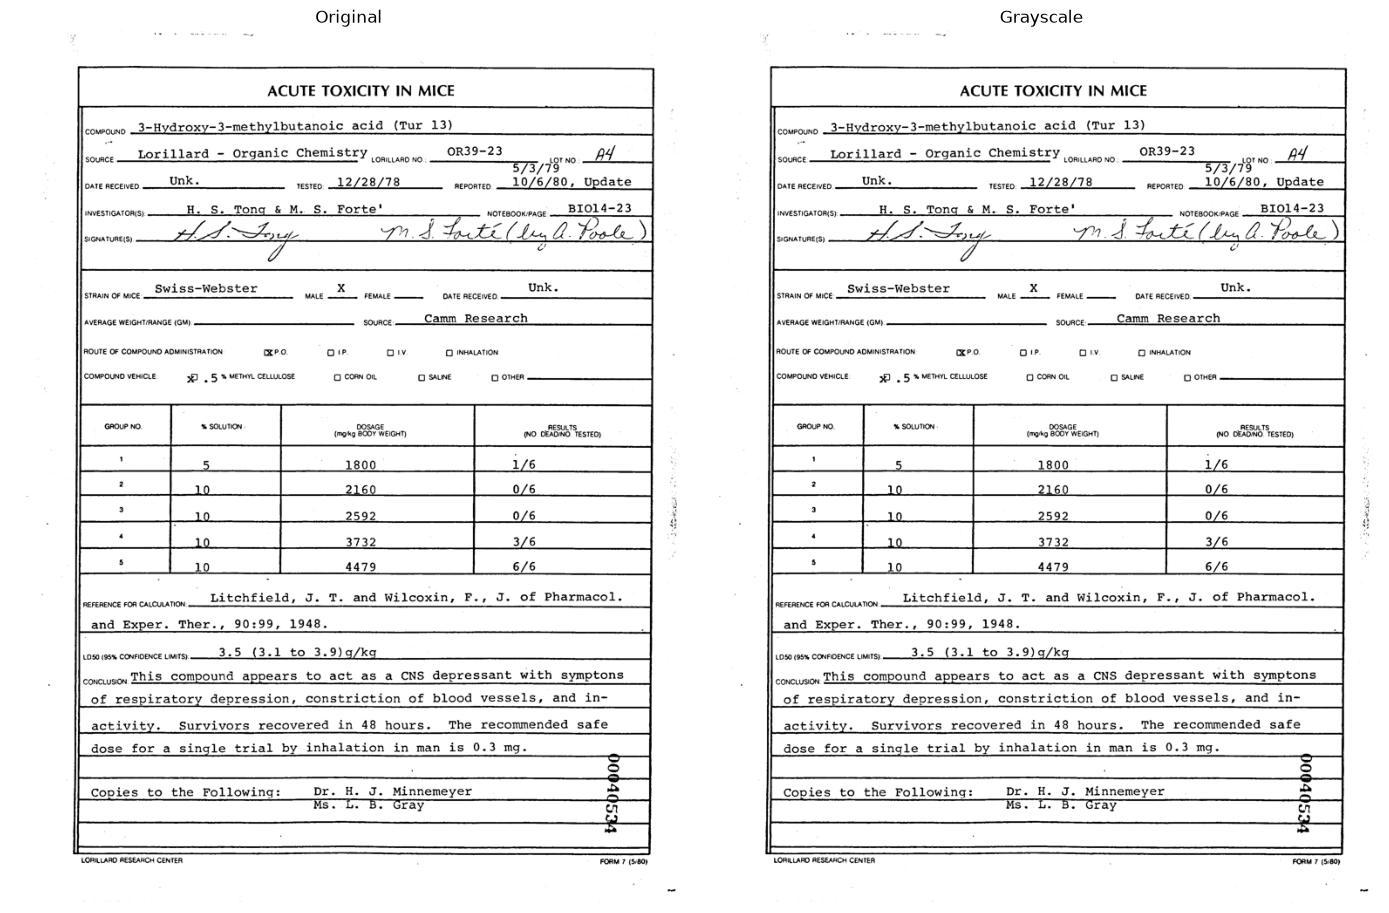

In [2]:
IMAGE_PATH = r"../data/raw/training_data/images/00040534.png"

img_bgr = cv2.imread(IMAGE_PATH)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

show_pair(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB), gray, "Original", "Grayscale")


## 2. Denoising

**What it does:** smooths out small, unwanted pixel variations (noise) while
trying to preserve sharp edges like text strokes.

**Why it's used in OCR:**
- Removes smudges and stray "salt-and-pepper" dots (common from dirty
  scanners) before binarization, so the threshold step doesn't pick them up
  as text.
- Prevents the OCR model from misreading a character due to extra noise
  pixels, e.g. a stray dot turning a "C" into something that looks like a
  "G".
- The end goal is to reduce Character Error Rate (CER) and Word Error Rate
  (WER) on the downstream OCR output.

**Filters tested:**
- `cv2.fastNlMeansDenoising` — best for severe stains, smudges, or variable
  background shadows. Good for heavily degraded historical or biological
  records.
- `cv2.medianBlur` — best for classic "salt-and-pepper" noise (tiny black/white
  dots from a dirty scanner glass).

**Other filters worth noting (not tested here, but relevant for future
degraded scans):**
- `cv2.morphologyEx` with `cv2.MORPH_OPEN` — removes background text
  bleed-through or leftover speckles after binarization.
- `cv2.GaussianBlur` — useful for low-light fuzz or camera sensor noise
  (e.g. photos taken on a phone rather than scanned).

**Observation on this dataset:** on a clean FUNSD scan, both filters produce
only a very subtle smoothing effect, there isn't much noise to remove. The
effect would be far more visible on a phone photo of a faded field label.

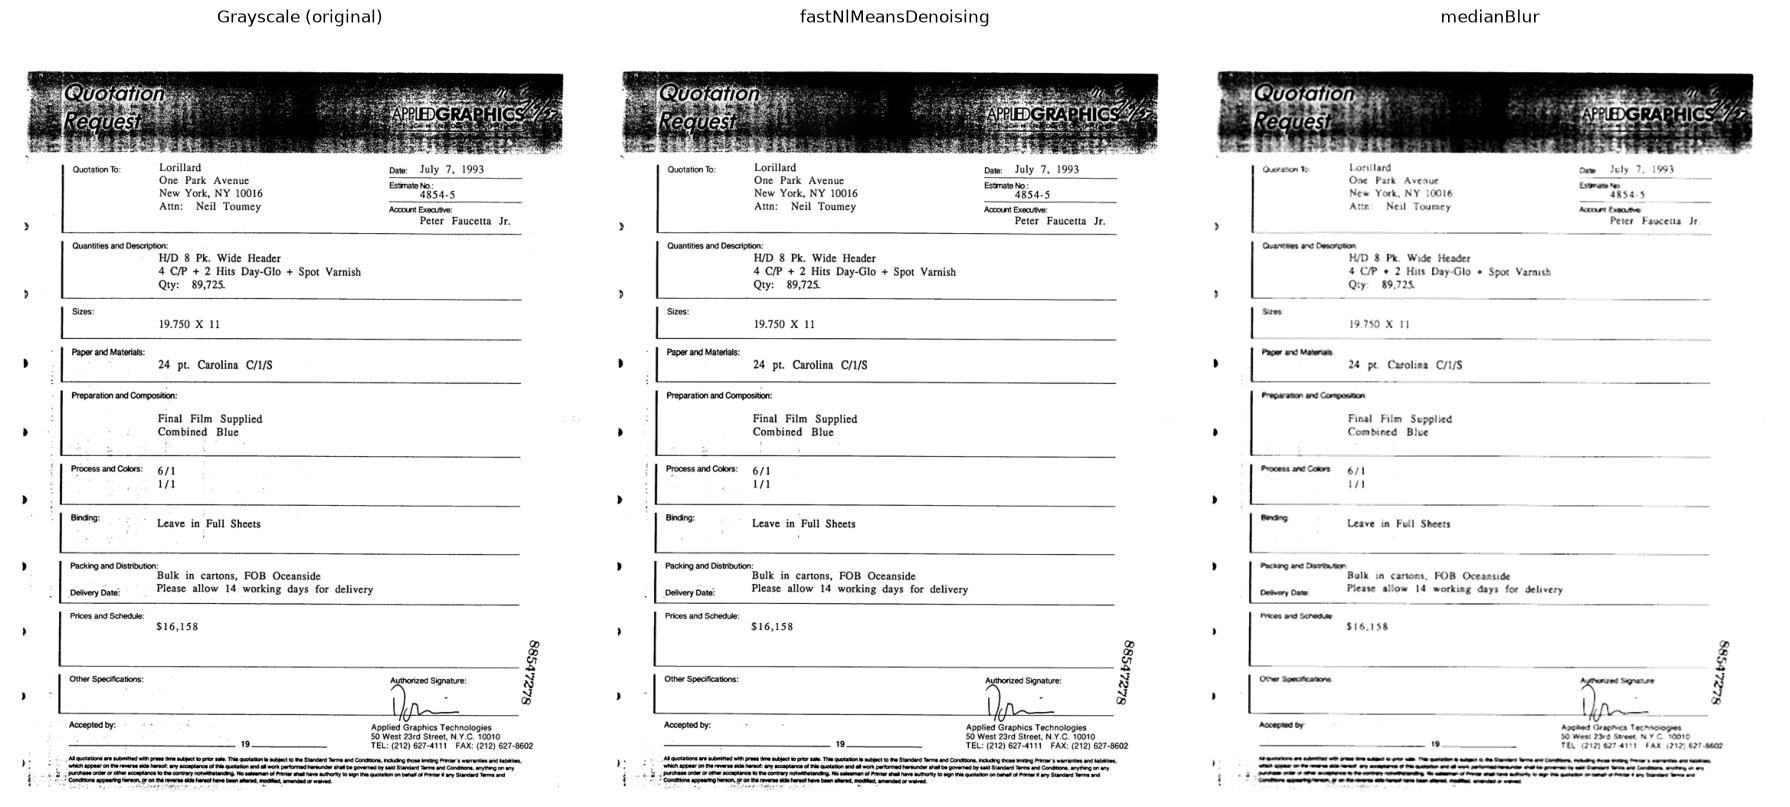

In [4]:
IMAGE_PATH = r"../data/raw/training_data/images/88547278_88547279.png"

img_bgr = cv2.imread(IMAGE_PATH)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

denoised_nlmeans = cv2.fastNlMeansDenoising(gray, None, h=10, templateWindowSize=7, searchWindowSize=21)
denoised_median = cv2.medianBlur(gray, 3)

fig, axes = plt.subplots(1, 3, figsize=(18, 10))
for ax, im, t in zip(axes, [gray, denoised_nlmeans, denoised_median],
                      ["Grayscale (original)", "fastNlMeansDenoising", "medianBlur"]):
    ax.imshow(im, cmap="gray")
    ax.set_title(t)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Contrast Limited Adaptive Histogram Equalization (CLAHE)

**What it does:** boosts local contrast by equalizing the histogram of small
tiles across the image independently, rather than applying a single global
contrast adjustment. The "contrast limited" part caps how aggressively any
one tile can be stretched, which avoids amplifying noise in flat regions.

**Why it's used in OCR:**
- Many real-world documents have *uneven* contrast, e.g. a faded pencil
  annotation in one corner and a dark ink stamp in another. A global
  contrast stretch can't fix both at once; CLAHE adapts locally.
- Improves separation between faint text and background before
  binarization, which is especially useful for old or low-quality scans
  (carbon copies, faded ink, photocopies of photocopies).

**Observation on this dataset:** the FUNSD scans already have high, even
contrast (dark printed/typed text on a bright white background), so CLAHE's
effect here is minimal, it mostly just slightly deepens the blacks. On a
faded handwritten specimen label, I'd expect this to matter much more.

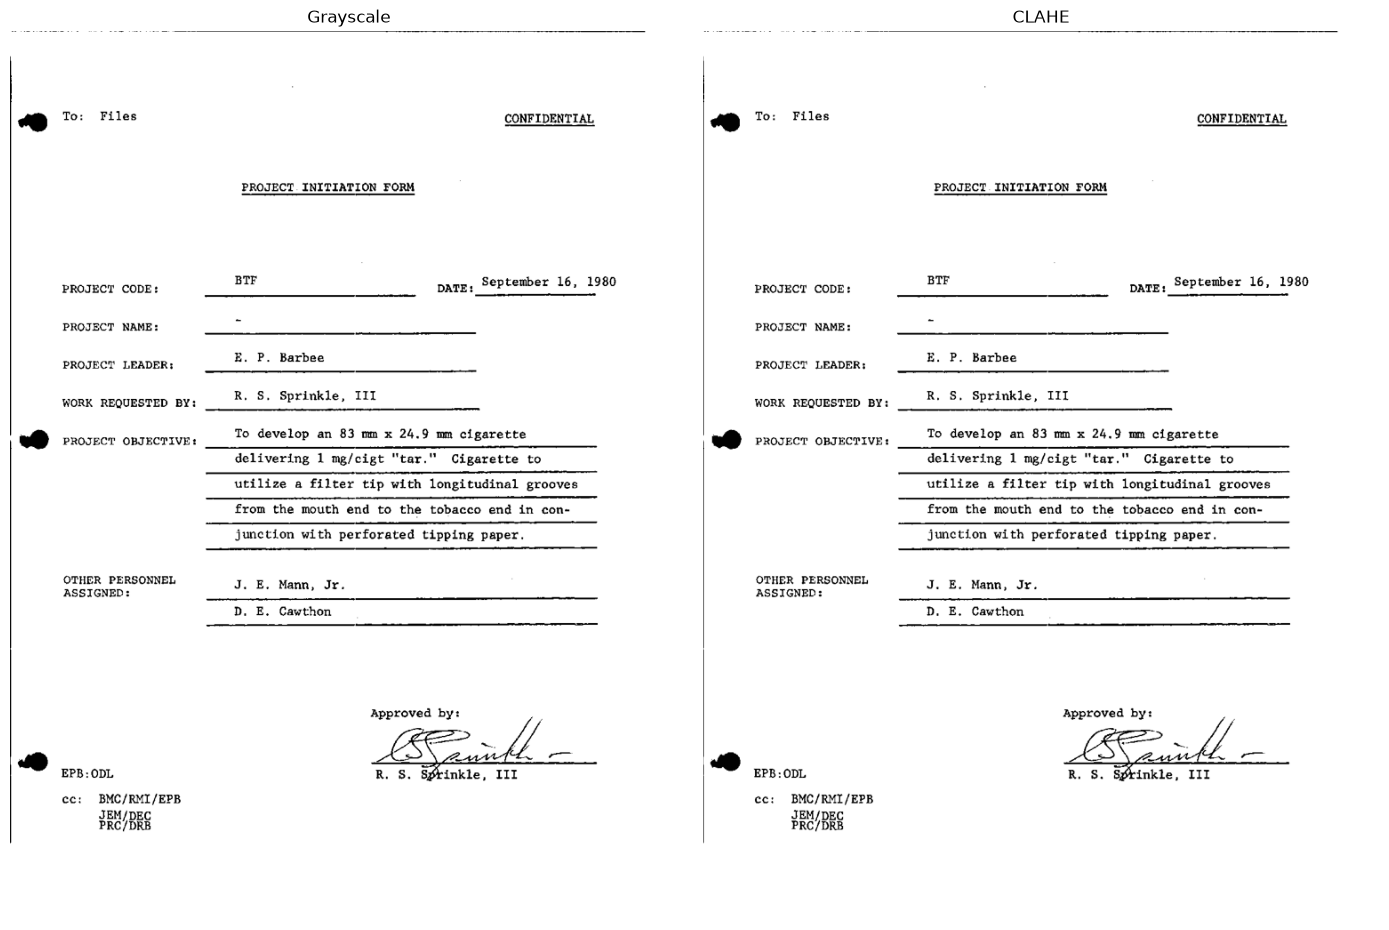

In [3]:
IMAGE_PATH = r"../data/raw/training_data/images/0071032790.png"

img_bgr = cv2.imread(IMAGE_PATH)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced = clahe.apply(gray)

show_pair(gray, enhanced, "Grayscale", "CLAHE")


## 4. Binarization / thresholding

**What it does:** converts a grayscale image to pure black-and-white by
classifying each pixel as either foreground (text) or background, based on
some intensity threshold.

**Why it's used in OCR:**
- Traditional OCR engines (e.g. Tesseract) were originally designed around
  binarized input, maximizing the contrast between ink and paper.
- Two common strategies were tested here:
  - **Otsu's method** — automatically picks a single *global* threshold for
    the whole image based on its histogram. Works well when lighting is
    uniform across the page.
  - **Adaptive thresholding** — computes a *local* threshold for each region,
    which handles documents with uneven lighting or shadows (e.g. a
    photographed page with a gradient from a desk lamp).

**Observation on this dataset / why this matters for the pipeline decision:**
binarization is the technique I'm *most cautious* about for this project.
Azure Document Intelligence's models are trained on natural document images
and can use grayscale/color information (font weight, anti-aliasing, subtle
contrast) that a hard black/white threshold throws away. Aggressively
binarizing a document that's already clean risks *removing* useful signal,
thin or light-weight text strokes can disappear entirely if the threshold is
too aggressive, which is exactly the kind of thing that increases CER on a OCR model.

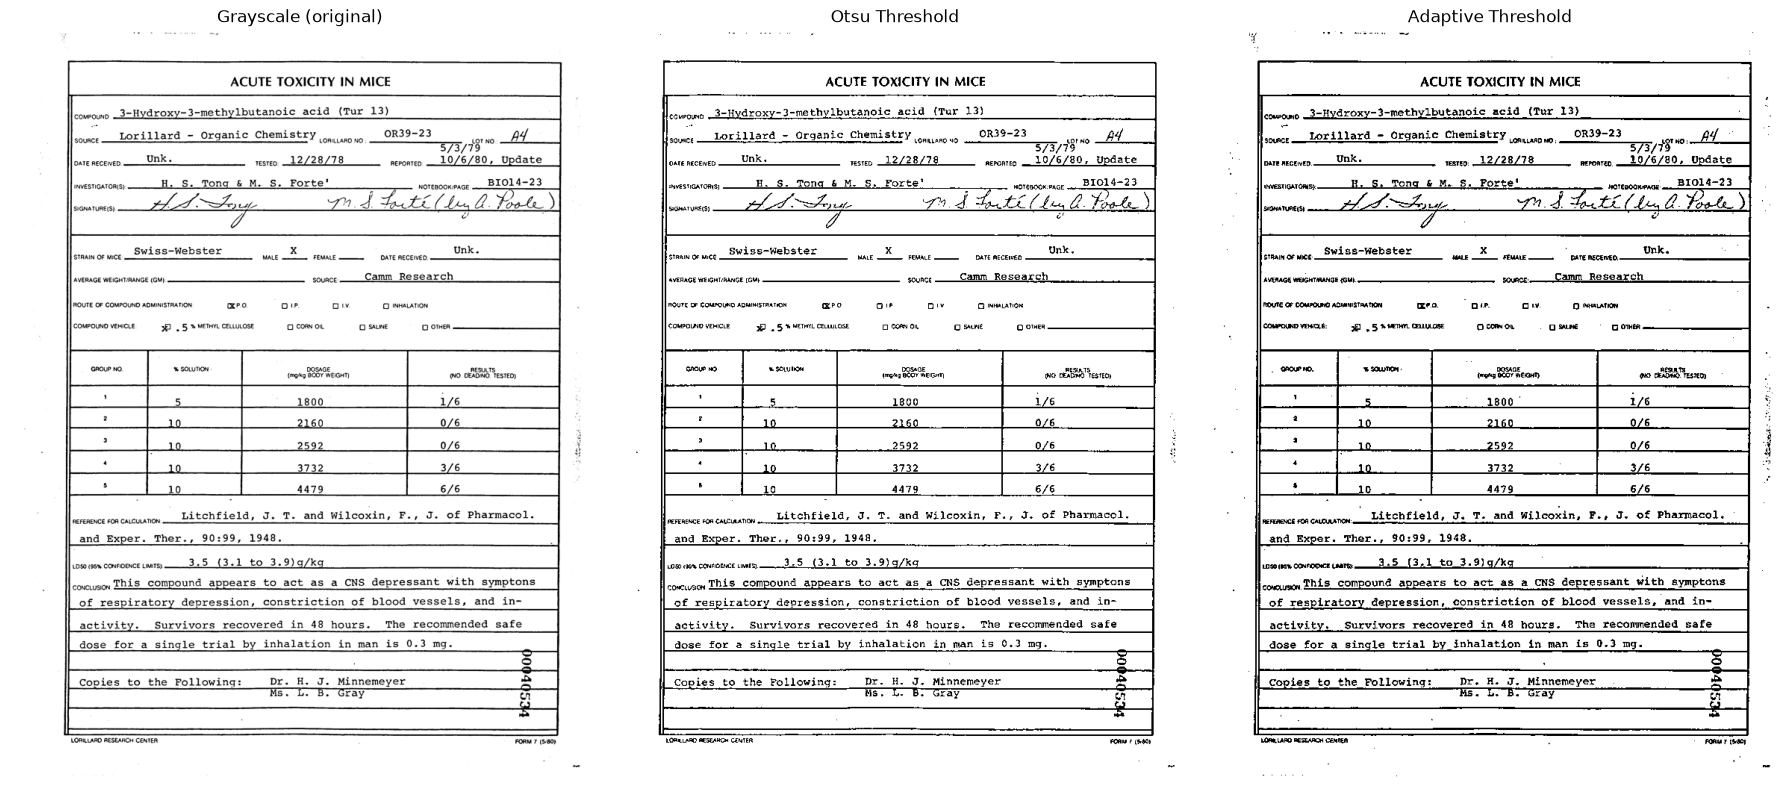

In [5]:
IMAGE_PATH = r"../data/raw/training_data/images/00040534.png"

img_bgr = cv2.imread(IMAGE_PATH)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Otsu's global threshold
_, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Adaptive threshold (local)
adaptive = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY, blockSize=35, C=15)

fig, axes = plt.subplots(1, 3, figsize=(18, 10))
for ax, im, t in zip(axes, [gray, otsu, adaptive],
                      ["Grayscale (original)", "Otsu Threshold", "Adaptive Threshold"]):
    ax.imshow(im, cmap="gray")
    ax.set_title(t)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 5. Deskew detection

**What it does:** estimates the rotation angle of the text/content on a page
(e.g. from a slightly crooked scan or photo) and rotates the image back to
horizontal.

**Why it's used in OCR:**
- Most OCR models, including line/word detectors, assume roughly
  horizontal text. Even a few degrees of skew can cause line-detection to
  merge or split lines incorrectly, or rotate bounding boxes in ways that
  break downstream geometry-based logic (like the FUNSD `box`
  [left, top, right, bottom] format used elsewhere in this project).
- The approach here: binarize the image, find all "ink" pixels, fit a
  minimum-area bounding rectangle around them, and use that rectangle's
  angle as the estimated skew. Then apply an affine rotation to correct it.

**Observation on this dataset:** FUNSD images are scanned (not photographed),
so they're essentially perfectly horizontal already, the detected skew angle
on this image is close to 0°. If incorrectly tuned, could mess up orientation of document.
This step would matter much more for phone-photographed field labels, which are rarely perfectly aligned.

Detected skew angle: 1.23 degrees


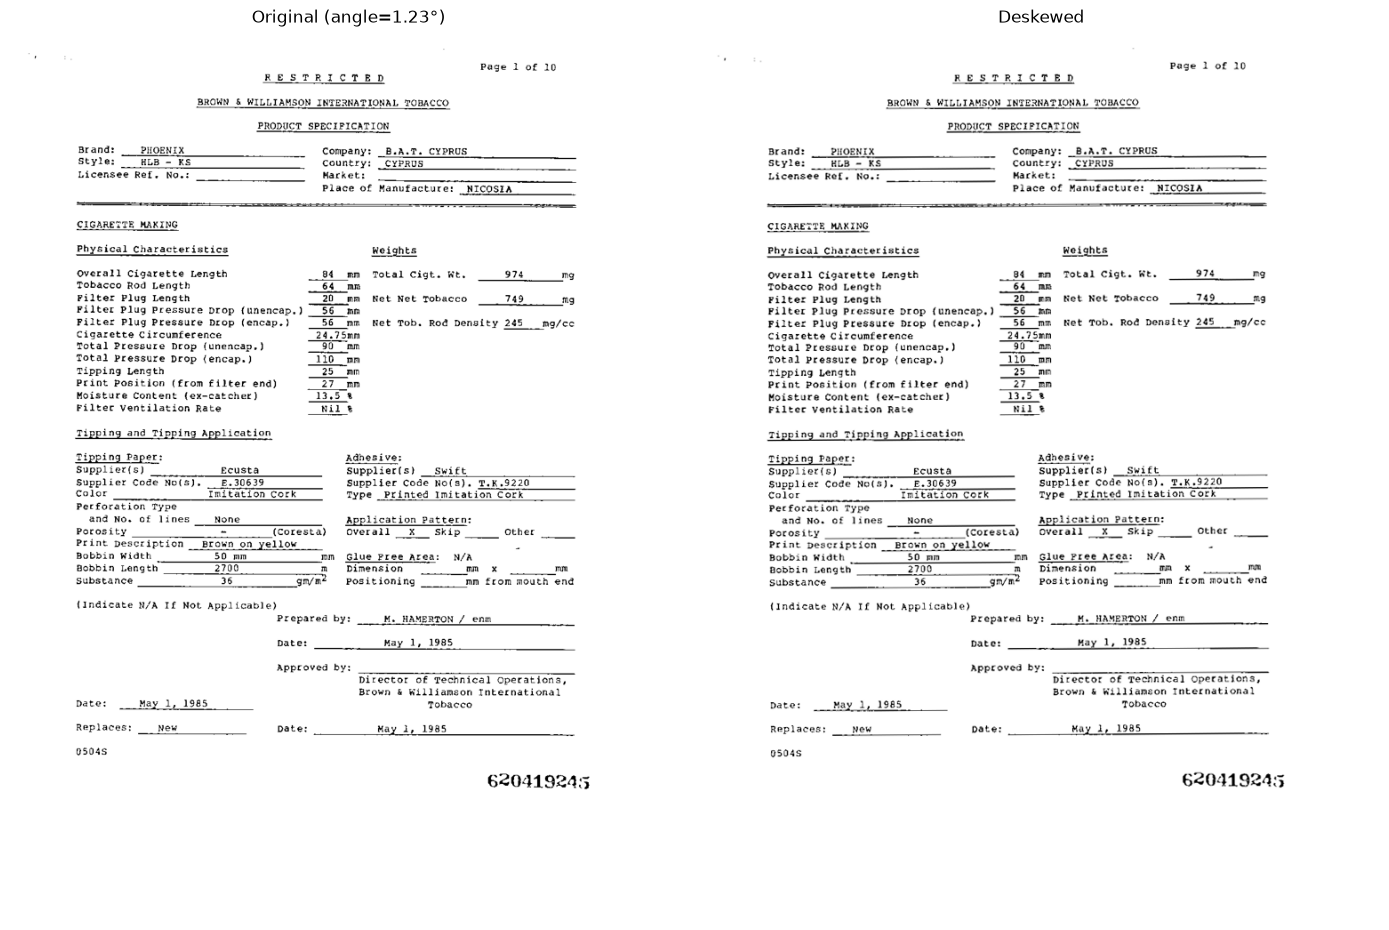

In [17]:
IMAGE_PATH = r"../data/raw/training_data/images/0000989556.png"

img_bgr = cv2.imread(IMAGE_PATH)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Binarize to find text pixels
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Find angle of the minimum-area rectangle around all text pixels
coords = np.column_stack(np.where(binary > 0))
angle = cv2.minAreaRect(coords)[-1]

# Normalize angle to a sensible range
if angle < -45:
    angle = 90 + angle

print(f"Detected skew angle: {angle:.2f} degrees")

# Apply rotation correction
(h, w) = gray.shape
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, angle/3, 1.0)
deskewed = cv2.warpAffine(gray, M, (w, h), flags=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_CONSTANT, borderValue=255)

show_pair(gray, deskewed, f"Original (angle={angle:.2f}°)", "Deskewed")


## 6. Removing artifacts / lines (morphological filtering)

**What it does:** uses a "structuring element" (a small kernel of a chosen
shape and size) to detect and remove specific shapes in a binary image,
long thin vertical lines in the case below, without affecting the surrounding text.

**Why it's used in OCR:**
- Forms and labels often contain ruled lines, table borders, or underlines
  that aren't part of the actual text content. Left in place, these lines
  can get merged into adjacent text bounding boxes or confuse a
  layout/table-detection model.
- `cv2.MORPH_OPEN` with a tall, thin kernel (e.g. 1px wide × 40px tall)
  isolates structures that are long and thin in the vertical direction
  (i.e. vertical lines) while ignoring individual characters, which are
  comparatively short and wide. Subtracting that result from the original
  binary image removes the lines while leaving the text intact.

**Observation on this dataset:** this is the most "surgical" of the
techniques tested, it's not a general preprocessing step, but useful for a
*specific* problem (ruled lines/borders interfering with parsing). Azure
Document Intelligence's layout model already handles tables and lines well
on its own for this dataset, so this wasn't needed in the final pipeline, but
it's a good tool to have on hand if a future document type (e.g. ruled
specimen log sheets) causes line-related parsing issues.

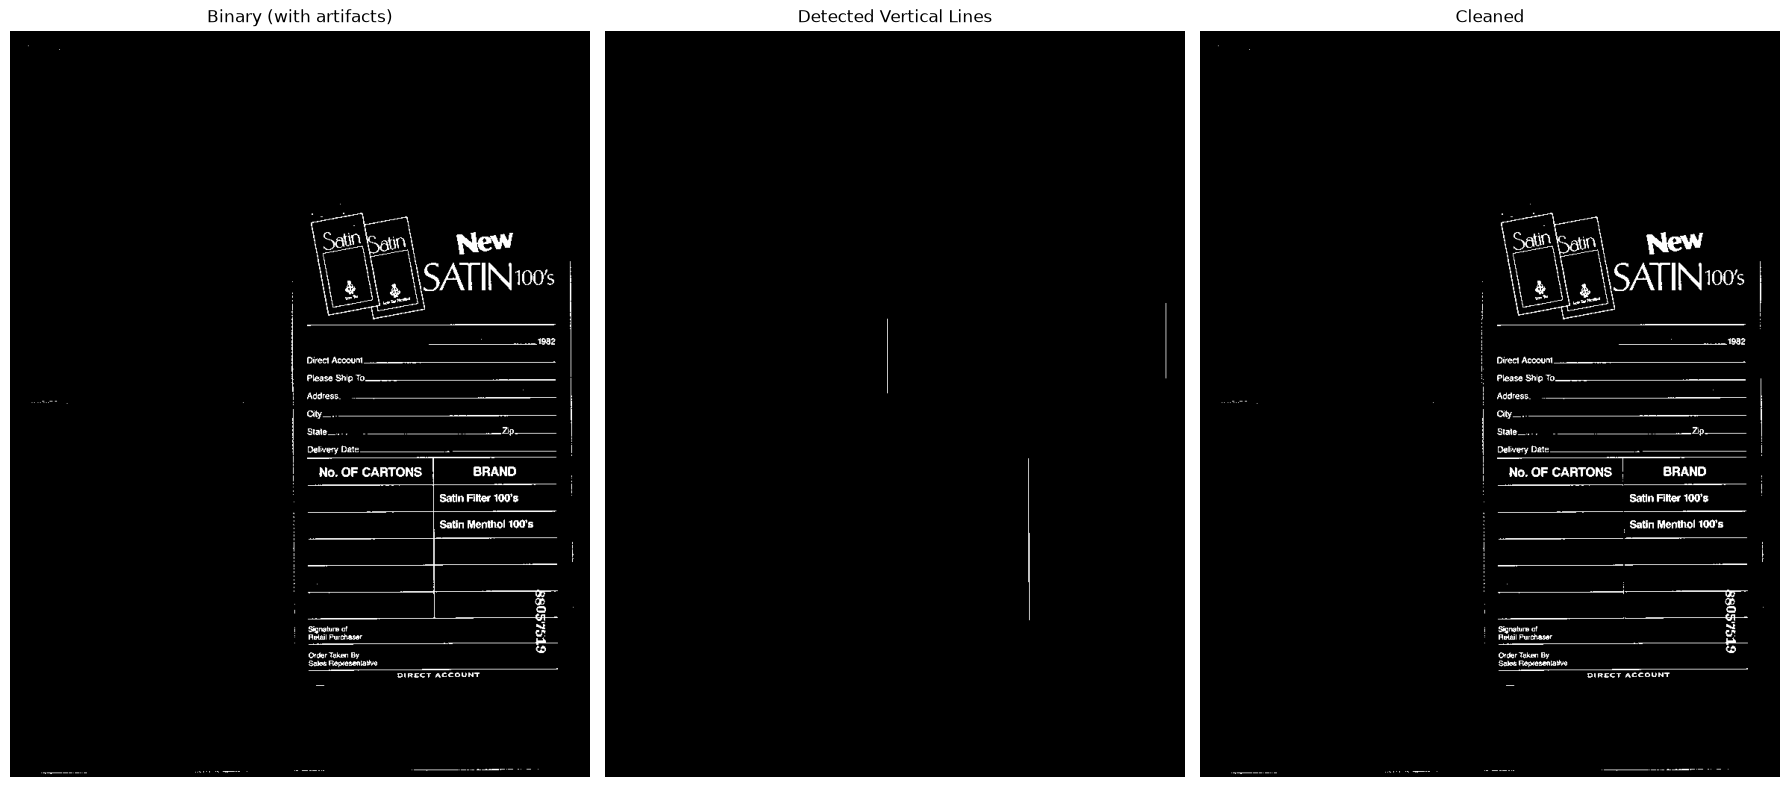

In [19]:
IMAGE_PATH = r"../data/raw/training_data/images/88057519.png"

img_bgr = cv2.imread(IMAGE_PATH)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Detect long vertical lines using a tall, thin kernel
vert_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 40))
vertical_lines = cv2.morphologyEx(binary, cv2.MORPH_OPEN, vert_kernel, iterations=2)

# Subtract detected lines from the binary image
cleaned = cv2.subtract(binary, vertical_lines)

fig, axes = plt.subplots(1, 3, figsize=(18, 10))
for ax, im, t in zip(axes, [binary, vertical_lines, cleaned],
                      ["Binary (with artifacts)", "Detected Vertical Lines", "Cleaned"]):
    ax.imshow(im, cmap="gray")
    ax.set_title(t)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 7. Putting it together: candidate preprocessing pipelines

To make a final decision, I combined the individual techniques above into
four candidate "versions" of increasing intensity, and generated all four for
the same source image so they could be compared side-by-side and (in
principle) sent to Azure Document Intelligence for an A/B comparison:

- **A — Raw:** no preprocessing at all (Azure sees the original image).
- **B — Grayscale + CLAHE:** the lightest-touch option — grayscale plus local
  contrast enhancement only.
- **C — Denoise + CLAHE:** adds noise reduction before contrast enhancement,
  for documents with visible smudging or speckling.
- **D — Full binarized:** the "traditional OCR" pipeline — grayscale,
  denoise, CLAHE, then adaptive thresholding to pure black/white.

Deskew and the morphological line-removal step were left out of these
combined versions since they're situational (only useful for skewed scans or
documents with stray ruled lines), rather than something to apply
universally.

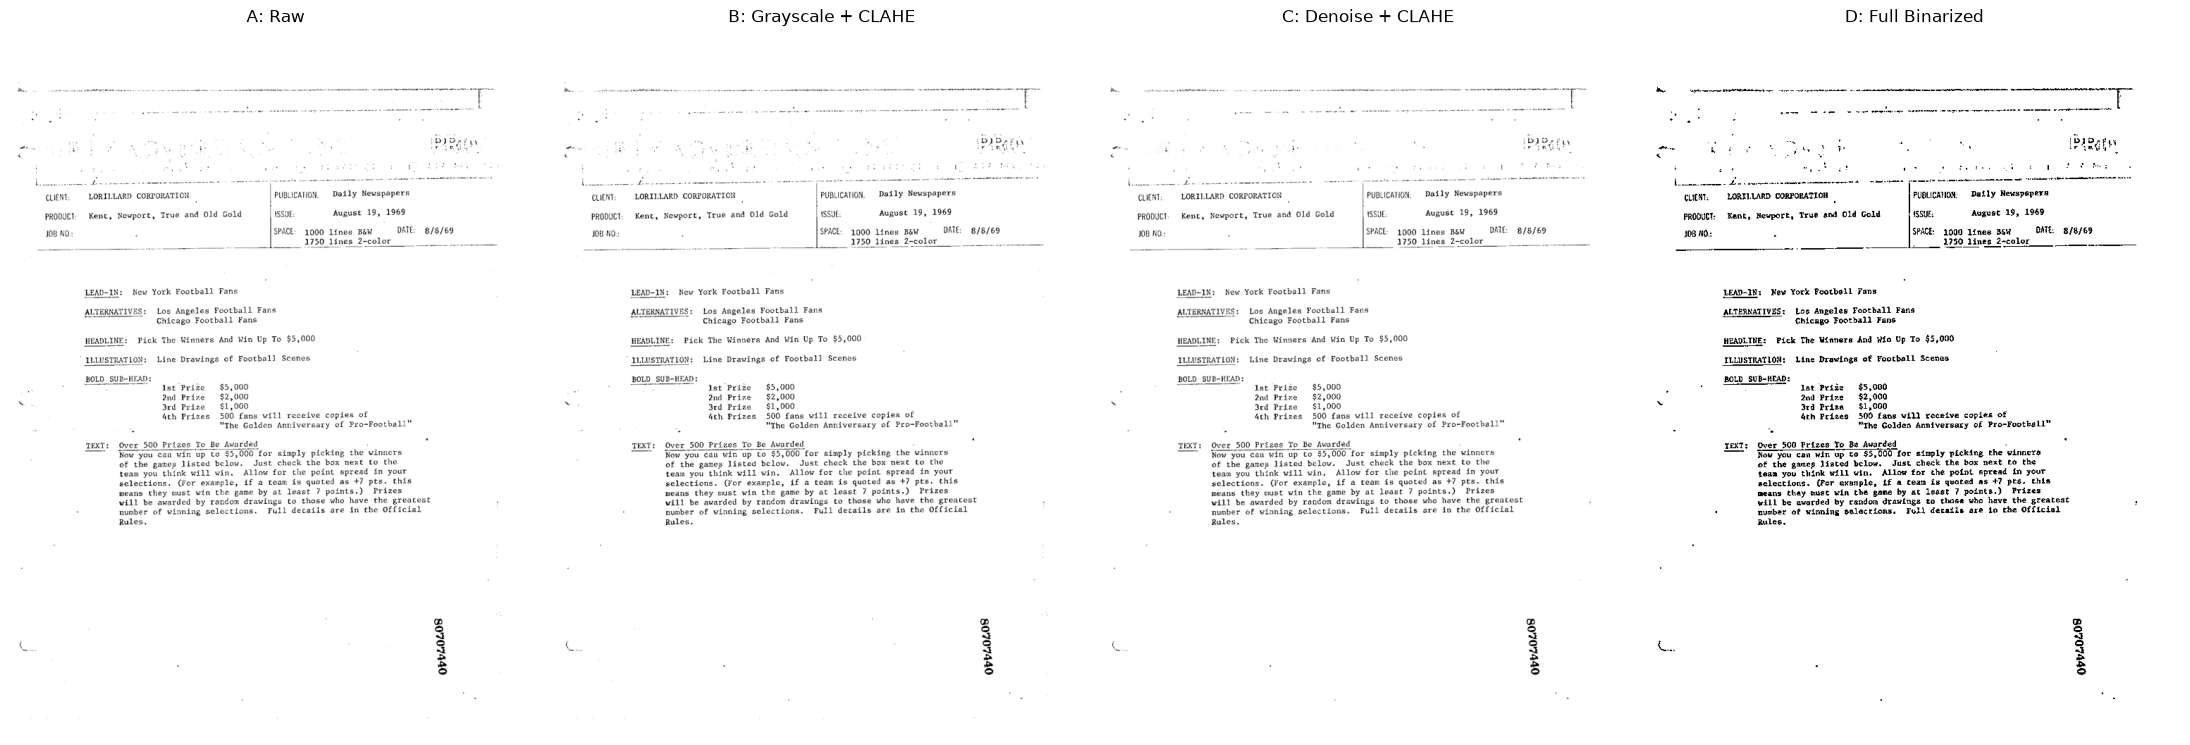

In [21]:
IMAGE_PATH = r"../data/raw/training_data/images/80707440_7443.png"
img_bgr = cv2.imread(IMAGE_PATH)


def version_a_raw(img_bgr):
    """Version A: no preprocessing — Azure gets the original image."""
    return img_bgr


def version_b_grayscale_clahe(img_bgr):
    """Version B: grayscale + contrast enhancement only."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray)


def version_c_denoise_clahe(img_bgr):
    """Version C: grayscale + denoise + contrast enhancement."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    denoised = cv2.fastNlMeansDenoising(gray, None, h=10, templateWindowSize=7, searchWindowSize=21)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(denoised)


def version_d_full_binarized(img_bgr):
    """Version D: grayscale + denoise + CLAHE + adaptive threshold (fully binarized)."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    denoised = cv2.fastNlMeansDenoising(gray, None, h=10, templateWindowSize=7, searchWindowSize=21)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)
    return cv2.adaptiveThreshold(enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY, blockSize=35, C=15)


# Generate all versions and display side-by-side
versions = {
    "A: Raw": version_a_raw(img_bgr),
    "B: Grayscale + CLAHE": version_b_grayscale_clahe(img_bgr),
    "C: Denoise + CLAHE": version_c_denoise_clahe(img_bgr),
    "D: Full Binarized": version_d_full_binarized(img_bgr),
}

fig, axes = plt.subplots(1, 4, figsize=(22, 10))
for ax, (name, im) in zip(axes, versions.items()):
    if im.ndim == 3:
        im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 8. Saving versions for A/B testing against Azure

Each version was saved to `data/processed/` so it could be sent through
`azure_client.analyze_document()` and the results compared via
`evaluator.OCREvaluator` (CER/WER against the FUNSD ground truth).

In [ ]:
# Saving versions for ADI (Azure Document Intelligence) testing

OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for name, im in versions.items():
    safe_name = name.split(":")[0]  # "A", "B", "C", "D"
    out_path = OUTPUT_DIR / f"version_{safe_name}.png"
    cv2.imwrite(str(out_path), im)
    print(f"Saved {name} -> {out_path}")


## Conclusion

Running versions A–D through Azure Document Intelligence and scoring the
results with `OCREvaluator` (CER/WER against FUNSD ground truth) confirmed
the hypothesis above:

- **Version A (raw)** performed at least as well as the preprocessed
  versions, in some cases better.
- **Version D (full binarization)** was the worst performer — the hard
  threshold removed subtle grayscale information Azure's model uses, which
  *increased* CER/WER rather than decreasing it.

**Decision for the production pipeline (`src/azure_client.py`):** send raw
images directly to Azure Document Intelligence, with **no OpenCV
preprocessing step**. This dataset's scans are clean enough that
preprocessing adds complexity and risk (especially binarization) without a
measurable accuracy benefit.

**Where this preprocessing *would* still be valuable:** if this pipeline is
later applied to noisier source material, like phone-photographed specimen
labels, faded historical field notes, or scans with visible skew/ruled
lines, the techniques explored here (denoising, CLAHE, deskewing,
morphological line removal) would be worth revisiting on a per-document or
per-batch basis, ideally with the same A/B-against-ground-truth methodology
used here rather than applied blindly.